# Structured NMF Demo: Recovering Age-Driven Gene Programs

Compares `AmortizedOnlineStructureAwareNMF` with standard `AmortizedOnlineNonNegativeMatrixFactorization`
on pbmc3k data with a simulated age effect.

**Scenario A (distinct):** the simulated age gene program is a random sparse direction, orthogonal to major cell-type variation.

**Scenario B (overlapping):** the simulated age gene program is a sparse mix of top PC directions, correlated with existing cell-type structure.

In [1]:
# ============================================================
# USER CONFIGURATION — edit these before running
# ============================================================

SCENARIO = "distinct"        # "distinct" or "overlapping"
EFFECT_FRACTION = 0.02       # fraction of total raw-count variance explained by the age program
                             # Note: real aging studies typically explain 1-5% of transcriptional variance.
                             #       2% is subtle but realistic; 5% is detectable but strong.

K_VALUES = list(range(5, 16))   # k sweep for both models
NMF_REPLICATES = 50             # replicates per k
MAX_EPOCHS = 100                # max training epochs; early stopping cuts this short
BATCH_SIZE = 512                # training batch size
LATENT_DIM = 64                 # encoder latent dimension

# Set these AFTER viewing the stability plots below
BEST_K_STANDARD = 9
BEST_K_STRUCTURED = 9

SEED = 0

In [2]:
import os
import warnings

import anndata
import numpy as np
import pandas as pd
import scipy.sparse
import scanpy as sc
import torch
import torch.nn.functional as F
import lightning.pytorch as pl
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, truncnorm
from sklearn.decomposition import TruncatedSVD

import cellarium.ml
import cellarium.ml.data
import cellarium.ml.models
import cellarium.ml.transforms
from cellarium.ml import CellariumAnnDataDataModule, CellariumModule
from cellarium.ml.models.nmf import NMFOutput, kotliar_compute_hvgs
from cellarium.ml.models.ols import StreamingOrdinaryLeastSquares
from cellarium.ml.utilities.data import AnnDataField, densify

os.environ["TORCH_COMPILE_DISABLE"] = "1"
warnings.filterwarnings("ignore", category=UserWarning)

os.makedirs("nmf_checkpoints", exist_ok=True)
os.makedirs("tmp", exist_ok=True)

/Users/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/google/api_core/_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


## Load pbmc3k and simulate age effect

In [3]:
# Load the processed pbmc3k object; .raw holds log1p-normalized counts
pbmc = sc.datasets.pbmc3k_processed()
pbmc_raw = pbmc.raw.to_adata()

# Reverse log1p to approximate raw UMI counts
X_dense = pbmc_raw.X.toarray() if scipy.sparse.issparse(pbmc_raw.X) else np.array(pbmc_raw.X)
X_raw = np.expm1(X_dense).astype(np.float32)
pbmc_raw.X = X_raw

# Add cell type annotation
pbmc_raw.obs["cell_type"] = pbmc.obs["louvain"].values

# Filter: remove MT genes, MALAT1, and genes expressed in fewer than 1/500 cells
pbmc_raw = pbmc_raw[:, ~pbmc_raw.var_names.str.startswith("MT-")].copy()
pbmc_raw = pbmc_raw[:, pbmc_raw.var_names != "MALAT1"].copy()
min_cells = pbmc_raw.n_obs / 500
gene_mask = (pbmc_raw.X > 0).sum(axis=0) >= min_cells
pbmc_raw = pbmc_raw[:, gene_mask].copy()
print(f"After filtering: {pbmc_raw.n_obs} cells, {pbmc_raw.n_vars} genes")

After filtering: 2638 cells, 12124 genes


Donor ages: [54.6 43.8 33.7 31.7 60.9 66.2 53.7 57.6 51.9 67.9 61.  30.3 62.9 33.1
 57.6 40.5 63.2 51.8 44.8 48.4]
  min=30.3, max=67.9, mean=50.8


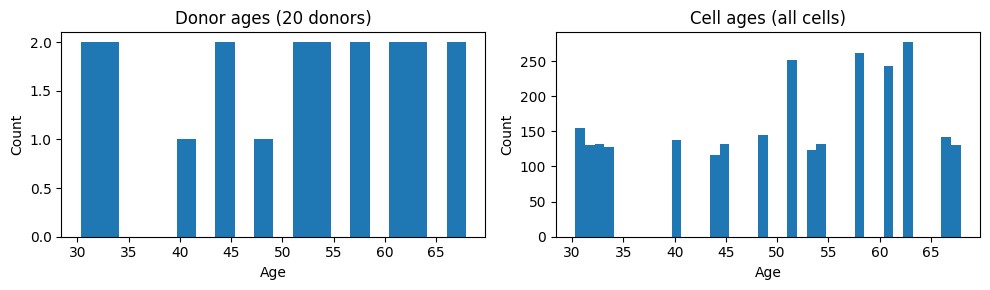

In [4]:
rng = np.random.default_rng(SEED)

N_DONORS = 20
# Truncated Gaussian: mean=50, std=12, clipped to [30, 80]
a_clip, b_clip = (30 - 50) / 12, (80 - 50) / 12
donor_ages = truncnorm.rvs(a_clip, b_clip, loc=50, scale=12, size=N_DONORS, random_state=rng).astype(np.float32)
print(f"Donor ages: {np.round(donor_ages, 1)}")
print(f"  min={donor_ages.min():.1f}, max={donor_ages.max():.1f}, mean={donor_ages.mean():.1f}")

# Randomly assign cells to donors
donor_ids = rng.integers(0, N_DONORS, size=pbmc_raw.n_obs)
ages_per_cell = donor_ages[donor_ids]

pbmc_raw.obs["donor_id"] = donor_ids.astype(str)
pbmc_raw.obs["age"] = ages_per_cell
pbmc_raw.obsm["metadata"] = ages_per_cell[:, None].astype(np.float32)  # (N, 1)

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(donor_ages, bins=20)
axes[0].set(title="Donor ages (20 donors)", xlabel="Age", ylabel="Count")
axes[1].hist(ages_per_cell, bins=40)
axes[1].set(title="Cell ages (all cells)", xlabel="Age", ylabel="Count")
plt.tight_layout()
plt.show()

In [5]:
def get_datamodule(adata: anndata.AnnData, batch_size: int = BATCH_SIZE) -> CellariumAnnDataDataModule:
    """Datamodule with x_ng (raw counts), var_names_g, obs_names_n, m_nd (age), and y_nk (age for OLS)."""
    dm = CellariumAnnDataDataModule(
        dadc=adata,
        batch_keys={
            "x_ng": AnnDataField(attr="X", convert_fn=densify),
            "var_names_g": AnnDataField(attr="var_names"),
            "obs_names_n": AnnDataField(attr="obs_names"),
            "m_nd": AnnDataField(attr="obsm", key="metadata"),
            "y_nk": AnnDataField(attr="obsm", key="metadata"),  # for OLS (same data, different key)
        },
        batch_size=batch_size,
    )
    dm.setup(stage="fit")
    return dm

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name     | Type              | Params | Mode 
-------------------------------------------------------
0 | pipeline | CellariumPipeline | 1      | train
-------------------------------------------------------
1         Trainable params
0         Non-trainable params
1         Total params
0.000     Total estimated model params size (MB)
4         Modules in train mode
0         Modules in eval mode


Epoch 0: 100%|██████████| 6/6 [00:00<00:00, 76.32it/s]

`Trainer.fit` stopped: `max_epochs=1` reached.


Epoch 0: 100%|██████████| 6/6 [00:00<00:00, 75.80it/s]
Selected 2000 highly variable genes


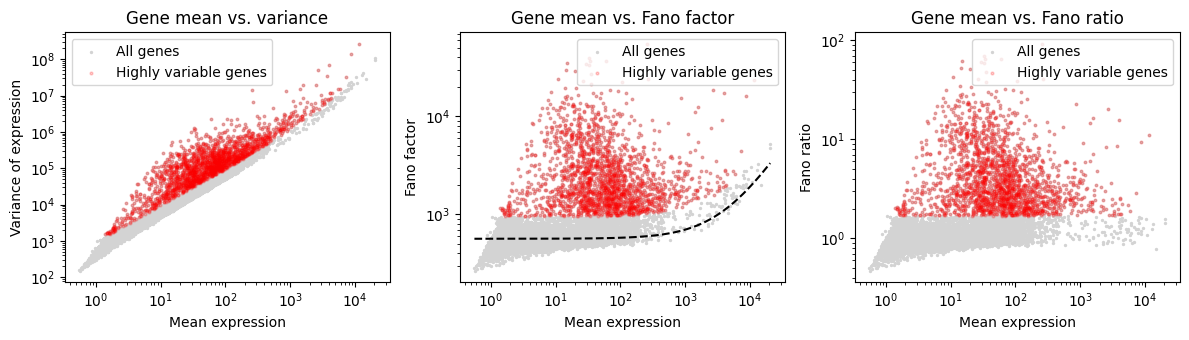

In [6]:
# Compute per-gene mean/var on TPM-normalized counts for Kotliar HVG selection.
# Run on pbmc_raw (before age effect) so hvg_var_names_g is known before constructing the age program.
tpm_onepass_module = CellariumModule(
    transforms=[
        cellarium.ml.transforms.Densify(),
        cellarium.ml.transforms.NormalizeTotal(target_count=1e6),
    ],
    model=cellarium.ml.models.OnePassMeanVarStd(
        var_names_g=pbmc_raw.var_names.to_numpy(),
    ),
)
trainer_tpm = pl.Trainer(accelerator="cpu", devices=1, max_epochs=1,
                          default_root_dir="tmp/onepass_tpm", enable_checkpointing=False, logger=False)
trainer_tpm.fit(tpm_onepass_module, get_datamodule(pbmc_raw))

tpm_onepass_df = pd.DataFrame({
    "mean_g": tpm_onepass_module.model.mean_g.numpy(),
    "var_g": (tpm_onepass_module.model.var_g + 1e-5).numpy(),
    "var_names_g": tpm_onepass_module.model.var_names_g,
}).set_index("var_names_g")

hvg_df = kotliar_compute_hvgs(
    mean_g=tpm_onepass_df["mean_g"].values,
    var_g=tpm_onepass_df["var_g"].values,
    var_names_g=tpm_onepass_df.index.to_numpy(),
    num_genes=2000,
    plot=True,
)

hvg_var_names_g = hvg_df.index[hvg_df["highly_variable"]].to_numpy()
print(f"Selected {len(hvg_var_names_g)} highly variable genes")

In [7]:
G_all = pbmc_raw.n_vars
_hvg_positions = np.where(np.isin(pbmc_raw.var_names, hvg_var_names_g))[0]

if SCENARIO == "distinct":
    n_age_genes = 500
    w_age_raw = np.zeros(G_all, dtype=np.float32)
    selected_genes = rng.choice(_hvg_positions, n_age_genes, replace=False)
    gene_weights = rng.exponential(1.0, n_age_genes).astype(np.float32)
    w_age_raw[selected_genes] = gene_weights
    w_age_raw /= w_age_raw.sum()
    print(f"Scenario A (distinct): random sparse program using {n_age_genes}/{G_all} genes (all HVGs)")
elif SCENARIO == "overlapping":
    X_centered = pbmc_raw.X - pbmc_raw.X.mean(axis=0)
    svd = TruncatedSVD(n_components=10, random_state=SEED)
    svd.fit(X_centered)
    n_pcs_mix = 5
    pc_weights = np.abs(rng.standard_normal(n_pcs_mix)).astype(np.float32)
    pc_weights /= pc_weights.sum()
    w_age_raw = np.abs(svd.components_[:n_pcs_mix]).T @ pc_weights
    w_age_raw = np.maximum(w_age_raw, 0)
    _non_hvg = np.ones(G_all, dtype=bool)
    _non_hvg[_hvg_positions] = False
    w_age_raw[_non_hvg] = 0
    top_idx = np.argsort(w_age_raw)[-500:]
    mask_age = np.zeros(G_all, dtype=bool)
    mask_age[top_idx] = True
    w_age_raw[~mask_age] = 0
    w_age_raw /= w_age_raw.sum()
    print(f"Scenario B (overlapping): PC-mix sparse program using {mask_age.sum()}/{G_all} genes (all HVGs)")

print(f"Age program: {(w_age_raw > 0).sum()} non-zero genes, max weight = {w_age_raw.max():.5f}")

Scenario A (distinct): random sparse program using 500/12124 genes (all HVGs)
Age program: 500 non-zero genes, max weight = 0.01341


In [8]:
# Compute effect_scale so that age contribution explains EFFECT_FRACTION of total raw variance.
# Var(age_contribution to gene g) = Var(age_cell) * effect_scale^2 * w_age_raw[g]^2
# Sum over genes: Var(age) * effect_scale^2 * ||w_age_raw||_2^2 = EFFECT_FRACTION * total_raw_var

var_ages = float(np.var(ages_per_cell))
total_raw_var = float(pbmc_raw.X.var(axis=0).sum())
w_l2_sq = float(np.sum(w_age_raw ** 2))

effect_scale = float(np.sqrt(EFFECT_FRACTION * total_raw_var / (var_ages * w_l2_sq)))
print(f"effect_scale:     {effect_scale:.2f}")
print(f"var(cell ages):   {var_ages:.2f}")
print(f"total raw var:    {total_raw_var:.2e}")
print(f"||w_age||_2^2:    {w_l2_sq:.6f}")
print(f"\nAt mean age ({donor_ages.mean():.0f}): max added counts per gene = "
      f"{donor_ages.mean() * effect_scale * w_age_raw.max():.2f}")
print(f"Note: effect_fraction of variance is approximate; CPM dilution occurs in the NMF preprocessing step.")

# Add age effect to raw counts
age_contribution = np.outer(ages_per_cell, w_age_raw) * effect_scale  # (N, G_all)
X_simulated = np.clip(pbmc_raw.X + age_contribution.astype(np.float32), 0, None)

pbmc_sim = pbmc_raw.copy()
pbmc_sim.X = X_simulated
print(f"\nSimulated data shape: {pbmc_sim.shape}")
print(f"Mean added counts per cell: {age_contribution.sum(axis=1).mean():.2f}")

effect_scale:     23.21
var(cell ages):   140.76
total raw var:    1.61e+04
||w_age||_2^2:    0.004240

At mean age (51): max added counts per gene = 15.81
Note: effect_fraction of variance is approximate; CPM dilution occurs in the NMF preprocessing step.

Simulated data shape: (2638, 12124)
Mean added counts per cell: 1175.55


In [9]:
# Compute per-gene std on SIMULATED counts (pbmc_sim).
# Must use pbmc_sim (not pbmc_raw) because age-program genes have substantially higher variance
# in pbmc_sim. Using pbmc_raw std would under-scale those genes in DivideByScale, amplifying
# the age signal relative to other genes and causing NMF to over-spend on it.
# HVG selection uses pbmc_raw (above) to avoid circular dependency.
dm_sim_onepass = get_datamodule(pbmc_sim)

raw_onepass_module = CellariumModule(
    transforms=[cellarium.ml.transforms.Densify()],
    model=cellarium.ml.models.OnePassMeanVarStd(
        var_names_g=pbmc_sim.var_names.to_numpy(),
    ),
)
trainer_raw = pl.Trainer(accelerator="cpu", devices=1, max_epochs=1,
                          default_root_dir="tmp/onepass_sim", enable_checkpointing=False, logger=False)
trainer_raw.fit(raw_onepass_module, dm_sim_onepass)

raw_onepass_df = pd.DataFrame({
    "mean_g": raw_onepass_module.model.mean_g.numpy(),
    "var_g": (raw_onepass_module.model.var_g + 1e-5).numpy(),
    "std_g": (raw_onepass_module.model.std_g + 1e-5).numpy(),
    "var_names_g": raw_onepass_module.model.var_names_g,
}).set_index("var_names_g")

print(f"raw_onepass_df shape: {raw_onepass_df.shape}")
raw_onepass_df.head()

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name     | Type              | Params | Mode 
-------------------------------------------------------
0 | pipeline | CellariumPipeline | 1      | train
-------------------------------------------------------
1         Trainable params
0         Non-trainable params
1         Total params
0.000     Total estimated model params size (MB)
3         Modules in train mode
0         Modules in eval mode


Epoch 0: 100%|██████████| 6/6 [00:00<00:00, 97.21it/s]

`Trainer.fit` stopped: `max_epochs=1` reached.


Epoch 0: 100%|██████████| 6/6 [00:00<00:00, 96.48it/s]
raw_onepass_df shape: (12124, 3)


,mean_g,var_g,std_g
var_names_g,,,
AL627309.1,0.003412,0.003410,0.058320
LINC00115,0.006823,0.006787,0.082331
NOC2L,0.107278,0.159464,0.399327
KLHL17,0.003033,0.003033,0.054995
PLEKHN1,0.002654,0.002656,0.051454


In [10]:
# OLS: regress scaled HVG expression (y) on raw age metadata (x)
# The NMF operates on x_scaled = X_raw / scale_g (no CPM), so OLS must use the same scaled space.
# We use raw (uncentered) age as the predictor, consistent with the model's m_nd convention.

hvg_mask = np.isin(pbmc_sim.var_names, hvg_var_names_g)
scale_g_hvg = raw_onepass_df.loc[hvg_var_names_g, "std_g"].values.astype(np.float32)  # (G_hvg,)
X_hvg_scaled = pbmc_sim.X[:, hvg_mask] / scale_g_hvg  # (N, G_hvg)

M_raw = pbmc_sim.obsm["metadata"].astype(np.float32)  # (N, 1), raw uncentered ages
G_hvg = X_hvg_scaled.shape[1]
D = M_raw.shape[1]

# StreamingOrdinaryLeastSquares: x_ng = M_raw (predictor), y_nk = X_scaled (targets)
# W_gk from solve() has shape (D, G_hvg) = ols_coeff_dg
ols_model = StreamingOrdinaryLeastSquares(
    var_names_g=np.array(["age"]),  # D=1 feature name for the metadata predictor
    n_targets=G_hvg,
    ridge_penalty=1e-4,
    univariate=False,
)

batch_size_ols = 256
for start in range(0, pbmc_sim.n_obs, batch_size_ols):
    x_batch = torch.from_numpy(M_raw[start : start + batch_size_ols])
    y_batch = torch.from_numpy(X_hvg_scaled[start : start + batch_size_ols])
    ols_model.update(x_batch, y_batch)

ols_coeff_dg = ols_model.solve().numpy()  # (D, G_hvg)
print(f"ols_coeff_dg shape: {ols_coeff_dg.shape}")

metadata_mean_d = M_raw.mean(axis=0).astype(np.float32)
metadata_min_d  = M_raw.min(axis=0).astype(np.float32)
metadata_max_d  = M_raw.max(axis=0).astype(np.float32)
mean_total_count = float(X_hvg_scaled.sum(axis=1).mean())
print(f"metadata_mean_d (mean age): {metadata_mean_d}")
print(f"metadata_min_d  (min age):  {metadata_min_d}")
print(f"metadata_max_d  (max age):  {metadata_max_d}")
print(f"mean_total_count (scaled space): {mean_total_count:.2f}")

ols_coeff_dg shape: (1, 2000)
metadata_mean_d (mean age): [50.652542]
metadata_min_d  (min age):  [30.30595]
metadata_max_d  (max age):  [67.92402]
mean_total_count (scaled space): 1407.37


## Standard NMF (AmortizedOnlineNonNegativeMatrixFactorization)

Trains on all k values in K_VALUES with NMF_REPLICATES replicates. Age metadata is not used.

In [11]:
import torch._dynamo
torch._dynamo.config.suppress_errors = True

dm = get_datamodule(pbmc_sim)

nmf_model_standard = cellarium.ml.models.AmortizedOnlineNonNegativeMatrixFactorization(
    var_names_g=list(hvg_var_names_g),
    k_values=K_VALUES,
    r=NMF_REPLICATES,
    latent_dim=LATENT_DIM,
    total_n_cells=pbmc_sim.n_obs,
    batch_size=BATCH_SIZE,
    exploration_epochs=20,
    max_cooldown_epochs=5,
)

nmf_module_standard = CellariumModule(
    transforms=[
        cellarium.ml.transforms.Filter(filter_list=list(hvg_var_names_g)),
        cellarium.ml.transforms.DivideByScale(
            scale_g=torch.from_numpy(raw_onepass_df["std_g"].values.astype(np.float32)),
            var_names_g=raw_onepass_df.index.to_numpy(),
            eps=1e-4,
        ),
    ],
    model=nmf_model_standard,
)

trainer_standard = pl.Trainer(
    accelerator="auto",
    devices=1,
    max_epochs=MAX_EPOCHS,
    default_root_dir="tmp/nmf_standard",
    log_every_n_steps=1,
    enable_checkpointing=False,
)

pl.seed_everything(SEED)
trainer_standard.fit(nmf_module_standard, dm)
trainer_standard.save_checkpoint("nmf_checkpoints/standard_nmf.ckpt")
print("Standard NMF checkpoint saved.")

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Seed set to 0

  | Name     | Type              | Params | Mode 
-------------------------------------------------------
0 | pipeline | CellariumPipeline | 256 K  | train
-------------------------------------------------------
256 K     Trainable params
0         Non-trainable params
256 K     Total params
1.024     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode


Epoch 21: 100%|██████████| 6/6 [00:03<00:00,  1.91it/s, v_num=15, rec_error=0.826, k=5_consensus_q75=0.0795, k=6_consensus_q75=0.055, k=7_consensus_q75=0.0967, k=8_consensus_q75=0.144, k=9_consensus_q75=0.205, k=10_consensus_q75=0.227, k=11_consensus_q75=0.273, k=12_consensus_q75=0.285, k=13_consensus_q75=0.293, k=14_consensus_q75=0.274, k=15_consensus_q75=0.278, k_training=11.00]Triggering cooldown for k=5 at step=132
Triggering cooldown for k=6 at step=132
Triggering cooldown for k=7 at step=132
Triggering cooldown for k=8 at step=132
Triggering cooldown for k=9 at step=132
Triggering cooldown for k=10 at step=132
Triggering cooldown for k=11 at step=132
Triggering cooldown for k=12 at step=132
Triggering cooldown for k=13 at step=132
Triggering cooldown for k=14 at step=132
Triggering cooldown for k=15 at step=132
Epoch 22:   0%|          | 0/6 [00:00<?, ?it/s, v_num=15, rec_error=0.826, k=5_consensus_q75=0.0761, k=6_consensus_q75=0.0527, k=7_consensus_q75=0.0906, k=8_consensus_q75=

W0916 00:53:32.570000 3644 site-packages/torch/_dynamo/convert_frame.py:2008] [0/8] torch._dynamo hit config.recompile_limit (8)
W0916 00:53:32.570000 3644 site-packages/torch/_dynamo/convert_frame.py:2008] [0/8]    function: 'inner' (/Users/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/torch/_dynamo/external_utils.py:67)
W0916 00:53:32.570000 3644 site-packages/torch/_dynamo/convert_frame.py:2008] [0/8]    last reason: 0/7: GLOBAL_STATE changed: grad_mode 
W0916 00:53:32.570000 3644 site-packages/torch/_dynamo/convert_frame.py:2008] [0/8] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W0916 00:53:32.570000 3644 site-packages/torch/_dynamo/convert_frame.py:2008] [0/8] To diagnose recompilation issues, see https://docs.pytorch.org/docs/main/user_guide/torch_compiler/compile/programming_model.recompilation.html


Epoch 26: 100%|██████████| 6/6 [00:12<00:00,  0.47it/s, v_num=15, rec_error=0.822, k=5_consensus_q75=0.0756, k=6_consensus_q75=0.0514, k=7_consensus_q75=0.0837, k=8_consensus_q75=0.127, k=9_consensus_q75=0.190, k=10_consensus_q75=0.218, k=11_consensus_q75=0.261, k=12_consensus_q75=0.276, k=13_consensus_q75=0.271, k=14_consensus_q75=0.261, k=15_consensus_q75=0.264, k_training=0.000]
Standard NMF checkpoint saved.


In [12]:
dm_output = get_datamodule(pbmc_sim)

nmf_output_standard = NMFOutput.from_checkpoints(
    checkpoint_paths=["nmf_checkpoints/standard_nmf.ckpt"],
    datamodule=dm_output,
)
nmf_output_standard

100%|██████████| 1/1 [00:00<00:00,  2.72it/s]


NMFOutput(
    nmf_module=CellariumModule(pipeline = CellariumPipeline(
          (0): Filter(filter_list=['ISG15' 'CPSF3L' 'MRPL20' ... 'SLC19A1' 'S100B' 'PRMT2'], ordering=True, allow_missing=False)
          (1): DivideByScale(scale_g=tensor([0.0583, 0.0823, 0.3993,  ..., 0.0550, 0.2150, 0.1620]), var_names_g=['AL627309.1' 'LINC00115' 'NOC2L' ... 'AL354822.1' 'PNRC2-1' 'SRSF10-1'], eps=0.0001)
          (2): OnlineNonNegativeMatrixFactorization()
        )),
    datamodule={Train dataloader: size=6}
        {Validation dataloader: size=0}
        {Test dataloader: None}
        {Predict dataloader: size=6}
)
with consensus []

cellarium.ml.models.nmf - INFO - Computing consensus factors with default hyperparameters...
cellarium.ml.models.nmf - INFO - Calculating reconstruction error (requires an entire pass through the data)...


100%|██████████| 6/6 [00:03<00:00,  1.98it/s]


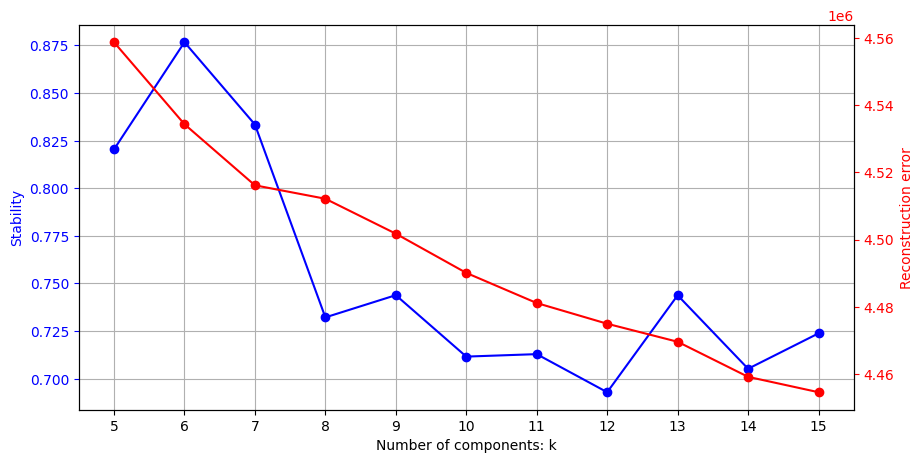

In [13]:
nmf_output_standard.default_k_selection_plot()

### Choose best k (standard NMF)

Look for a peak in stability above. Set `BEST_K_STANDARD` in the configuration cell and re-run from here.

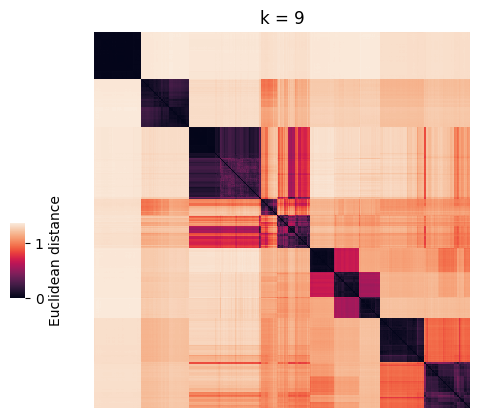

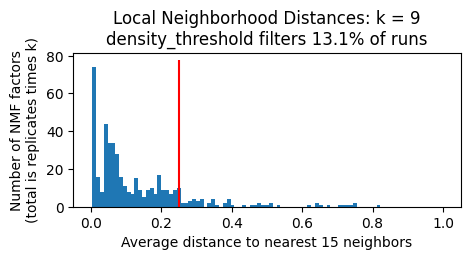

In [14]:
nmf_output_standard.plot_clustermap(k=9, density_threshold=0.25)

In [15]:
df_loadings_standard = nmf_output_standard.compute_loadings(k=BEST_K_STANDARD, normalize=False)
print(f"Loadings shape: {df_loadings_standard.shape}")
df_loadings_standard.head()

100%|██████████| 6/6 [00:00<00:00, 15.55it/s]

Loadings shape: (2638, 9)


,0,1,2,3,4,5,6,7,8
AAACATACAACCAC-1,8.398193,447.448303,0.000000,39.574604,0.000000,0.000000,866.949890,16.857330,2.461134
AAACATTGAGCTAC-1,38.489635,412.827850,0.000000,15.018577,306.686127,45.418175,923.460632,69.012054,0.000000
AAACATTGATCAGC-1,10.606632,534.701721,7.333021,0.810519,0.000000,55.491596,862.241394,133.639984,0.000000
AAACCGTGCTTCCG-1,135.354919,98.735138,14.650618,1.952847,4.202146,238.561295,594.312805,24.705189,46.483047
AAACCGTGTATGCG-1,54.930679,74.056381,0.000000,109.878929,0.020200,15.638360,1046.012207,27.932133,0.000000


Standard NMF (k=9): donor-level Spearman rho with age
  Program  6: rho=+0.995  p=0.000
  Program  7: rho=+0.468  p=0.038
  Program  8: rho=+0.405  p=0.077
  Program  0: rho=-0.395  p=0.084
  Program  1: rho=-0.314  p=0.177
  Program  3: rho=+0.272  p=0.246
  Program  2: rho=-0.071  p=0.767
  Program  5: rho=-0.069  p=0.772
  Program  4: rho=-0.039  p=0.870

Max |rho| across programs: 0.995


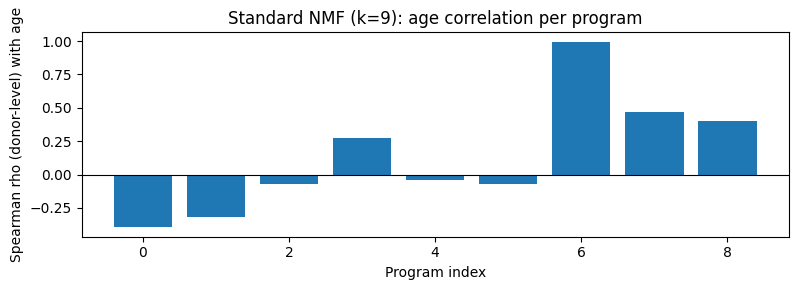

In [16]:
factor_cols_std = list(range(BEST_K_STANDARD))

df_std = df_loadings_standard.copy()
df_std["age"] = pbmc_sim.obs.loc[df_std.index, "age"].values
df_std["donor_id"] = pbmc_sim.obs.loc[df_std.index, "donor_id"].values

# Donor-level mean loadings
donor_means_std = df_std.groupby("donor_id")[factor_cols_std + ["age"]].mean()

age_corr_standard = {}
for fac in factor_cols_std:
    rho, pval = spearmanr(donor_means_std[fac], donor_means_std["age"])
    age_corr_standard[fac] = (rho, pval)

print(f"Standard NMF (k={BEST_K_STANDARD}): donor-level Spearman rho with age")
for fac, (rho, pval) in sorted(age_corr_standard.items(), key=lambda x: -abs(x[1][0])):
    print(f"  Program {fac:2d}: rho={rho:+.3f}  p={pval:.3f}")

max_rho_std = max(abs(v[0]) for v in age_corr_standard.values())
print(f"\nMax |rho| across programs: {max_rho_std:.3f}")

plt.figure(figsize=(8, 3))
rhos_std = [age_corr_standard[fac][0] for fac in factor_cols_std]
plt.bar(factor_cols_std, rhos_std)
plt.axhline(0, color="k", linewidth=0.8)
plt.xlabel("Program index")
plt.ylabel("Spearman rho (donor-level) with age")
plt.title(f"Standard NMF (k={BEST_K_STANDARD}): age correlation per program")
plt.tight_layout()
plt.show()

## Structured NMF (AmortizedOnlineStructureAwareNMF)

Uses donor age as explicit metadata. Factor 0 is nominated as the metadata-driven factor,
initialized from OLS coefficients. Group Lasso on Beta prunes spurious nominated factors.

In [17]:
nmf_model_structured = cellarium.ml.models.AmortizedOnlineStructureAwareNMF(
    var_names_g=list(hvg_var_names_g),
    k_values=K_VALUES,
    r=NMF_REPLICATES,
    latent_dim=LATENT_DIM,
    total_n_cells=pbmc_sim.n_obs,
    batch_size=BATCH_SIZE,
    exploration_epochs=20,
    max_cooldown_epochs=5,
    n_metadata=D,
    metadata_mean_d=metadata_mean_d,
    metadata_min_d=metadata_min_d,
    metadata_max_d=metadata_max_d,
    n_metadata_programs=2,          # nominate 2 factors; group lasso prunes to the genuine one(s)
    ols_coeff_dg=ols_coeff_dg,
    mean_total_count=mean_total_count,
    lambda_align=0.1,
    # lambda_select=0.05,
    lambda_select=0.0,
)

nmf_module_structured = CellariumModule(
    transforms=[
        cellarium.ml.transforms.Filter(filter_list=list(hvg_var_names_g)),
        cellarium.ml.transforms.DivideByScale(
            scale_g=torch.from_numpy(raw_onepass_df["std_g"].values.astype(np.float32)),
            var_names_g=raw_onepass_df.index.to_numpy(),
            eps=1e-4,
        ),
    ],
    model=nmf_model_structured,
)

trainer_structured = pl.Trainer(
    accelerator="auto",
    devices=1,
    max_epochs=MAX_EPOCHS,
    default_root_dir="tmp/nmf_structured",
    log_every_n_steps=1,
    enable_checkpointing=False,
)

pl.seed_everything(SEED)
trainer_structured.fit(nmf_module_structured, dm)
trainer_structured.save_checkpoint("nmf_checkpoints/structured_nmf.ckpt")
print("Structured NMF checkpoint saved.")

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Seed set to 0

  | Name     | Type              | Params | Mode 
-------------------------------------------------------
0 | pipeline | CellariumPipeline | 256 K  | train
-------------------------------------------------------
256 K     Trainable params
0         Non-trainable params
256 K     Total params
1.024     Total estimated model params size (MB)
9         Modules in train mode
0         Modules in eval mode


Epoch 21: 100%|██████████| 6/6 [00:05<00:00,  1.10it/s, v_num=12, rec_error=0.828, k=5_consensus_q75=0.0399, k=6_consensus_q75=0.0343, k=7_consensus_q75=0.024, k=8_consensus_q75=0.0972, k=9_consensus_q75=0.105, k=10_consensus_q75=0.156, k=11_consensus_q75=0.179, k=12_consensus_q75=0.253, k=13_consensus_q75=0.269, k=14_consensus_q75=0.233, k=15_consensus_q75=0.271, k_training=11.00] Triggering cooldown for k=5 at step=132
Triggering cooldown for k=6 at step=132
Triggering cooldown for k=7 at step=132
Triggering cooldown for k=8 at step=132
Triggering cooldown for k=9 at step=132
Triggering cooldown for k=10 at step=132
Triggering cooldown for k=11 at step=132
Triggering cooldown for k=12 at step=132
Triggering cooldown for k=13 at step=132
Triggering cooldown for k=14 at step=132
Triggering cooldown for k=15 at step=132
Epoch 26: 100%|██████████| 6/6 [00:14<00:00,  0.41it/s, v_num=12, rec_error=0.824, k=5_consensus_q75=0.035, k=6_consensus_q75=0.0318, k=7_consensus_q75=0.013, k=8_consen

In [18]:
# from_checkpoints extracts W factors into a shell OnlineNonNegativeMatrixFactorization.
# This is correct: post-training analysis uses consensus W for FISTA-based loadings,
# agnostic to the H_raw + H_struct decomposition from training.
nmf_output_structured = NMFOutput.from_checkpoints(
    checkpoint_paths=["nmf_checkpoints/structured_nmf.ckpt"],
    datamodule=dm_output,
)
nmf_output_structured

100%|██████████| 1/1 [00:00<00:00,  1.71it/s]


NMFOutput(
    nmf_module=CellariumModule(pipeline = CellariumPipeline(
          (0): Filter(filter_list=['ISG15' 'CPSF3L' 'MRPL20' ... 'SLC19A1' 'S100B' 'PRMT2'], ordering=True, allow_missing=False)
          (1): DivideByScale(scale_g=tensor([0.0583, 0.0823, 0.3993,  ..., 0.0550, 0.2150, 0.1620]), var_names_g=['AL627309.1' 'LINC00115' 'NOC2L' ... 'AL354822.1' 'PNRC2-1' 'SRSF10-1'], eps=0.0001)
          (2): OnlineNonNegativeMatrixFactorization()
        )),
    datamodule={Train dataloader: size=6}
        {Validation dataloader: size=0}
        {Test dataloader: None}
        {Predict dataloader: size=6}
)
with consensus []

cellarium.ml.models.nmf - INFO - Computing consensus factors with default hyperparameters...
cellarium.ml.models.nmf - INFO - Calculating reconstruction error (requires an entire pass through the data)...


100%|██████████| 6/6 [00:02<00:00,  2.02it/s]


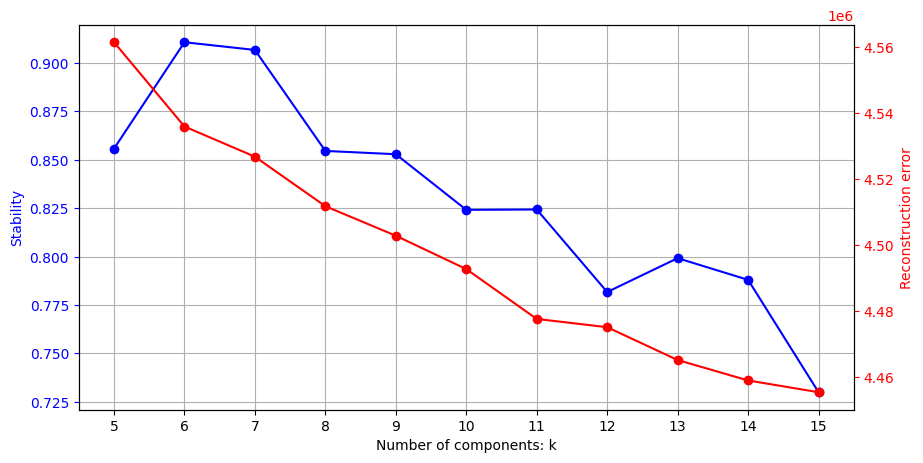

In [19]:
nmf_output_structured.default_k_selection_plot()

### Choose best k (structured NMF)

Look for a peak in stability above. Set `BEST_K_STRUCTURED` in the configuration cell and re-run from here.

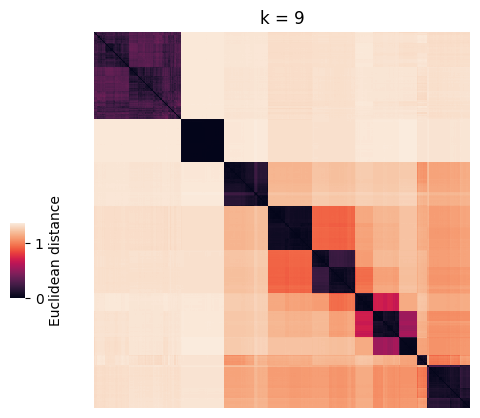

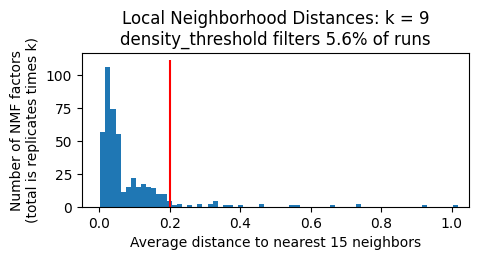

In [20]:
nmf_output_structured.plot_clustermap(k=9, density_threshold=0.2)

In [21]:
df_loadings_structured = nmf_output_structured.compute_loadings(k=BEST_K_STRUCTURED, normalize=False)
print(f"Loadings shape: {df_loadings_structured.shape}")
df_loadings_structured.head()

100%|██████████| 6/6 [00:00<00:00, 19.46it/s]

Loadings shape: (2638, 9)


,0,1,2,3,4,5,6,7,8
AAACATACAACCAC-1,288.284912,1051.375610,0.000000,7.371959,37.948013,0.000000,0.000000,0.000000,0.314783
AAACATTGAGCTAC-1,263.442139,1124.774170,0.000000,28.200607,19.270599,48.517757,302.770508,19.154070,0.000000
AAACATTGATCAGC-1,380.932098,1101.561157,7.603212,9.829526,14.395972,59.975193,0.000000,25.892097,0.000000
AAACCGTGCTTCCG-1,61.389988,673.824829,14.425169,120.075996,3.901369,231.843414,4.388268,9.038779,41.279671
AAACCGTGTATGCG-1,42.282326,1095.770508,0.000000,49.046844,116.928116,15.799720,0.000000,6.356537,0.000000


Structured NMF (k=9): donor-level Spearman rho with age
  Program  1: rho=+1.000  p=0.000
  Program  7: rho=+0.418  p=0.067
  Program  8: rho=+0.371  p=0.107
  Program  0: rho=-0.341  p=0.141
  Program  4: rho=+0.331  p=0.154
  Program  3: rho=-0.325  p=0.162
  Program  2: rho=-0.068  p=0.777
  Program  5: rho=-0.042  p=0.860
  Program  6: rho=-0.003  p=0.990

Max |rho| across programs: 1.000


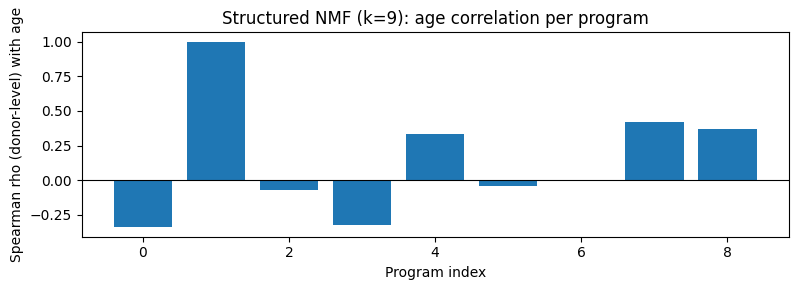

In [22]:
factor_cols_str = list(range(BEST_K_STRUCTURED))

df_str = df_loadings_structured.copy()
df_str["age"] = pbmc_sim.obs.loc[df_str.index, "age"].values
df_str["donor_id"] = pbmc_sim.obs.loc[df_str.index, "donor_id"].values

donor_means_str = df_str.groupby("donor_id")[factor_cols_str + ["age"]].mean()

age_corr_structured = {}
for fac in factor_cols_str:
    rho, pval = spearmanr(donor_means_str[fac], donor_means_str["age"])
    age_corr_structured[fac] = (rho, pval)

print(f"Structured NMF (k={BEST_K_STRUCTURED}): donor-level Spearman rho with age")
for fac, (rho, pval) in sorted(age_corr_structured.items(), key=lambda x: -abs(x[1][0])):
    print(f"  Program {fac:2d}: rho={rho:+.3f}  p={pval:.3f}")

max_rho_str = max(abs(v[0]) for v in age_corr_structured.values())
print(f"\nMax |rho| across programs: {max_rho_str:.3f}")

plt.figure(figsize=(8, 3))
rhos_str = [age_corr_structured[fac][0] for fac in factor_cols_str]
plt.bar(factor_cols_str, rhos_str)
plt.axhline(0, color="k", linewidth=0.8)
plt.xlabel("Program index")
plt.ylabel("Spearman rho (donor-level) with age")
plt.title(f"Structured NMF (k={BEST_K_STRUCTURED}): age correlation per program")
plt.tight_layout()
plt.show()

## Recovery Analysis (Structured NMF)

Check whether the structured NMF recovered the true simulated age gene program.

In [23]:
# The simulation adds age * effect_scale * w_age_raw to raw counts.
# After Filter(HVGs) + DivideByScale(scale_g), the NMF sees:
#   x_scaled_hvg = X_raw_hvg / scale_g_hvg
# The age contribution in scaled HVG space (per unit age) is:
#   effect_scale * w_age_raw_hvg / scale_g_hvg

w_age_raw_hvg = w_age_raw[hvg_mask]  # (G_hvg,), restricted to HVGs
w_age_true_scaled = w_age_raw_hvg / scale_g_hvg  # (G_hvg,), in NMF space

# L1-normalize to match the model's W convention (L1-norm = 1)
w_age_true_norm = w_age_true_scaled / (np.abs(w_age_true_scaled).sum() + 1e-8)

print(f"True age program (scaled): {(w_age_true_norm > 0).sum()} non-zero HVG genes")
print(f"L1 norm: {np.abs(w_age_true_norm).sum():.4f}")

True age program (scaled): 500 non-zero HVG genes
L1 norm: 1.0000


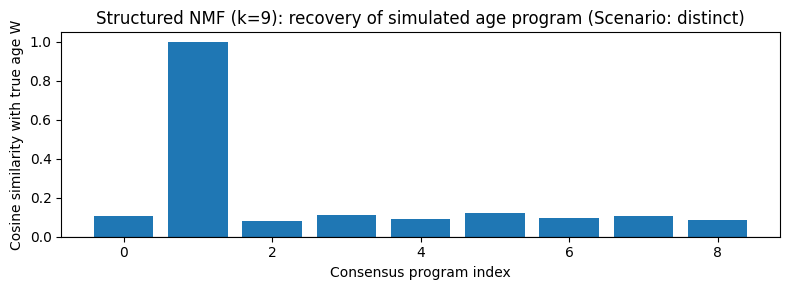

Best recovered program: index 1, cos_sim = 0.999


In [24]:
consensus_D_kg = nmf_output_structured.consensus[BEST_K_STRUCTURED]["consensus_D_kg"]  # (K, G_hvg)
w_true_t = torch.from_numpy(w_age_true_norm).float().unsqueeze(0)  # (1, G_hvg)

cos_sims = []
for k_idx in range(BEST_K_STRUCTURED):
    w_k = consensus_D_kg[k_idx].unsqueeze(0)  # (1, G_hvg)
    cs = F.cosine_similarity(w_true_t, w_k).item()
    cos_sims.append(cs)

plt.figure(figsize=(8, 3))
bars = plt.bar(range(BEST_K_STRUCTURED), cos_sims)
plt.axhline(0, color="k", linewidth=0.8)
plt.xlabel("Consensus program index")
plt.ylabel("Cosine similarity with true age W")
plt.title(f"Structured NMF (k={BEST_K_STRUCTURED}): recovery of simulated age program (Scenario: {SCENARIO})")
plt.tight_layout()
plt.show()

best_prog_idx = int(np.argmax(np.abs(cos_sims)))
print(f"Best recovered program: index {best_prog_idx}, cos_sim = {cos_sims[best_prog_idx]:.3f}")

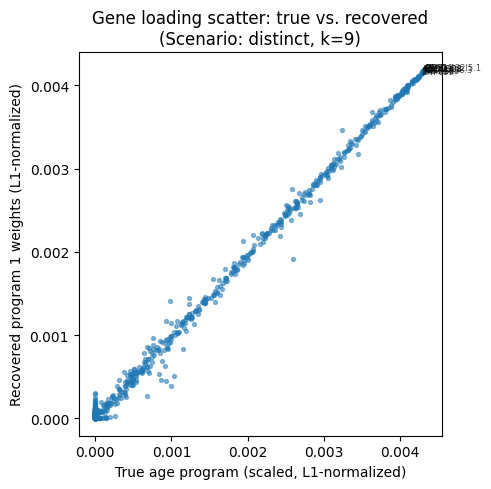

In [25]:
w_recovered = consensus_D_kg[best_prog_idx].numpy()  # (G_hvg,)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(w_age_true_norm, w_recovered, s=8, alpha=0.5)
ax.set_xlabel("True age program (scaled, L1-normalized)")
ax.set_ylabel(f"Recovered program {best_prog_idx} weights (L1-normalized)")
ax.set_title(f"Gene loading scatter: true vs. recovered\n(Scenario: {SCENARIO}, k={BEST_K_STRUCTURED})")

# Annotate top genes
top_true_idx = np.argsort(w_age_true_norm)[-10:]
for g_idx in top_true_idx:
    if w_age_true_norm[g_idx] > 0 or w_recovered[g_idx] > w_recovered.max() * 0.5:
        ax.annotate(hvg_var_names_g[g_idx], (w_age_true_norm[g_idx], w_recovered[g_idx]),
                    fontsize=6, alpha=0.7)
plt.tight_layout()
plt.show()

Analytic ground truth Beta (min-max units): 732.8688
  (range_age=37.62, effect_scale=23.21, ||w_scaled||_L1=0.8394)
Model Beta (program 1): mean=345.3620, std=18.0624
Ratio model/truth: 0.471


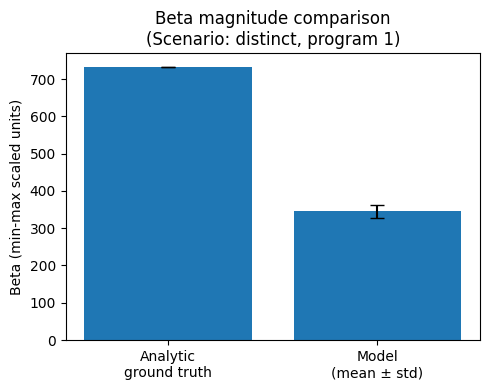

In [26]:
# Analytic ground truth Beta (min-max scaling model):
# The simulation adds: delta_X[i, g] = age_i * effect_scale * w_age_raw_hvg[g] / scale_g_hvg[g]
# The model uses: H_struct_i = M_scaled_i * Beta_j, where M_scaled = (age - min_age) / range_age
# Matching age-varying parts:
#   (age_i - min_age) / range_age * Beta_j = effect_scale * ||w_scaled||_L1 * age_i  [age-varying part]
# => Beta_true ≈ range_age * effect_scale * ||w_scaled||_L1
range_age = float(ages_per_cell.max() - ages_per_cell.min())
beta_true_analytic = float(range_age * effect_scale * np.abs(w_age_true_scaled).sum())
print(f"Analytic ground truth Beta (min-max units): {beta_true_analytic:.4f}")
print(f"  (range_age={range_age:.2f}, effect_scale={effect_scale:.2f}, ||w_scaled||_L1={np.abs(w_age_true_scaled).sum():.4f})")

# Model Beta: load checkpoint and read beta_{k}_rdk buffer for the best program
ckpt_module = CellariumModule.load_from_checkpoint(
    "nmf_checkpoints/structured_nmf.ckpt", map_location="cpu", strict=False
)
beta_rdk = getattr(ckpt_module.model, f"beta_{BEST_K_STRUCTURED}_rdk").detach()  # (R, D, K)
beta_model_per_replicate = beta_rdk[:, 0, best_prog_idx].numpy()  # (R,) — one per replicate
beta_model_mean = float(beta_model_per_replicate.mean())
beta_model_std = float(beta_model_per_replicate.std())

print(f"Model Beta (program {best_prog_idx}): mean={beta_model_mean:.4f}, std={beta_model_std:.4f}")
print(f"Ratio model/truth: {beta_model_mean / (beta_true_analytic + 1e-8):.3f}")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Analytic\nground truth", "Model\n(mean ± std)"],
       [beta_true_analytic, beta_model_mean],
       yerr=[0, beta_model_std], capsize=5)
ax.set_ylabel("Beta (min-max scaled units)")
ax.set_title(f"Beta magnitude comparison\n(Scenario: {SCENARIO}, program {best_prog_idx})")
plt.tight_layout()
plt.show()

## Comparison: Standard vs. Structured NMF

Model                            Max |rho| with age
-------------------------------------------------------
Standard NMF (k=9)                            0.995
Structured NMF (k=9)                          1.000



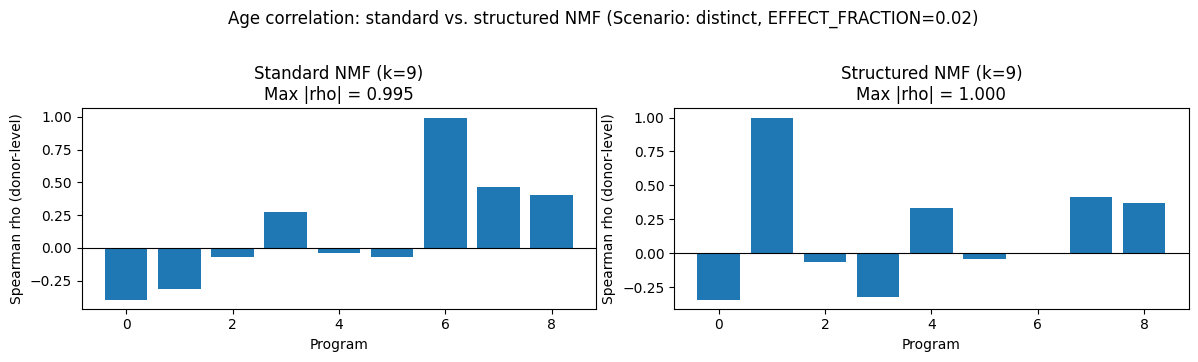

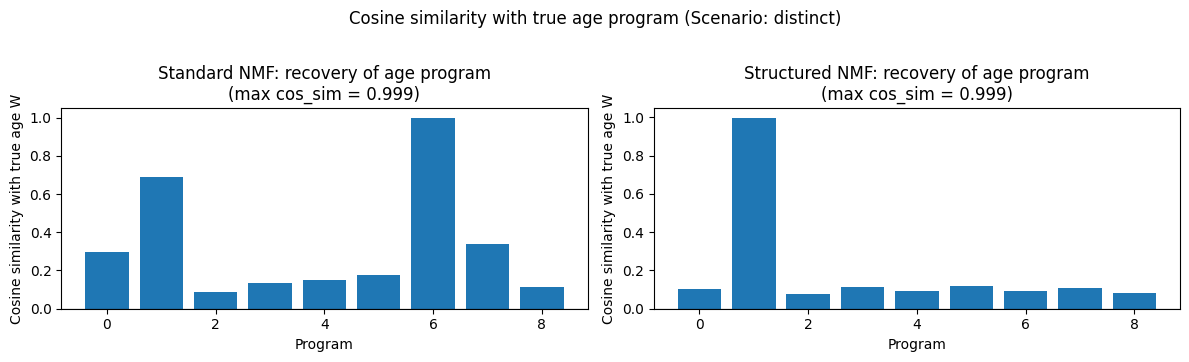

In [27]:
print("=" * 55)
print(f"{'Model':<30} {'Max |rho| with age':>20}")
print("-" * 55)
print(f"{'Standard NMF (k=' + str(BEST_K_STANDARD) + ')':<30} {max_rho_std:>20.3f}")
print(f"{'Structured NMF (k=' + str(BEST_K_STRUCTURED) + ')':<30} {max_rho_str:>20.3f}")
print("=" * 55)
print()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=False)

axes[0].bar(factor_cols_std, rhos_std)
axes[0].axhline(0, color="k", linewidth=0.8)
axes[0].set(xlabel="Program", ylabel="Spearman rho (donor-level)",
            title=f"Standard NMF (k={BEST_K_STANDARD})\nMax |rho| = {max_rho_std:.3f}")

axes[1].bar(factor_cols_str, rhos_str)
axes[1].axhline(0, color="k", linewidth=0.8)
axes[1].set(xlabel="Program", ylabel="Spearman rho (donor-level)",
            title=f"Structured NMF (k={BEST_K_STRUCTURED})\nMax |rho| = {max_rho_str:.3f}")

plt.suptitle(f"Age correlation: standard vs. structured NMF (Scenario: {SCENARIO}, EFFECT_FRACTION={EFFECT_FRACTION})",
             y=1.02)
plt.tight_layout()
plt.show()

# Also show cosine similarity of standard NMF programs with the true age direction
consensus_D_kg_std = nmf_output_standard.consensus[BEST_K_STANDARD]["consensus_D_kg"]  # (K, G_hvg)
cos_sims_std = [F.cosine_similarity(w_true_t, consensus_D_kg_std[k_idx].unsqueeze(0)).item()
                for k_idx in range(BEST_K_STANDARD)]

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].bar(range(BEST_K_STANDARD), cos_sims_std)
axes[0].axhline(0, color="k", linewidth=0.8)
axes[0].set(xlabel="Program", ylabel="Cosine similarity with true age W",
            title=f"Standard NMF: recovery of age program\n(max cos_sim = {max(np.abs(cos_sims_std)):.3f})")

axes[1].bar(range(BEST_K_STRUCTURED), cos_sims)
axes[1].axhline(0, color="k", linewidth=0.8)
axes[1].set(xlabel="Program", ylabel="Cosine similarity with true age W",
            title=f"Structured NMF: recovery of age program\n(max cos_sim = {max(np.abs(cos_sims)):.3f})")

plt.suptitle(f"Cosine similarity with true age program (Scenario: {SCENARIO})", y=1.02)
plt.tight_layout()
plt.show()